# Exploratory Data Analysis — AI-Based NIDS
**Dataset:** CICIDS2017 (Canadian Institute for Cybersecurity)  
**Purpose:** Understand the dataset before modelling — class distribution, feature overview, imbalance analysis, and feature importance.

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

ROOT = Path("..")
sns.set_theme(style="darkgrid")
print("Imports OK")

Imports OK


---
## Section A — Dataset Shape & Overview

In [15]:
df = pd.read_csv(ROOT / "data/processed/combined_dataset.csv")
print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(f"Features: {len(df.columns) - 1}  (excluding Label)")
df.head(3)

Rows    : 2,827,876
Columns : 79
Features: 78  (excluding Label)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [16]:
# Missing / inf values check (after cleaning)
inf_count = np.isinf(df.select_dtypes(include='number')).sum().sum()
nan_count = df.isna().sum().sum()
print(f"Inf values  : {inf_count}")
print(f"NaN values  : {nan_count}")
print("Dataset is clean — all inf/NaN were removed during combine_datasets.py")

Inf values  : 0
NaN values  : 0
Dataset is clean — all inf/NaN were removed during combine_datasets.py


---
## Section B — Class Distribution & Imbalance

In [17]:
counts = df["Label"].value_counts()
pct = (counts / len(df) * 100).round(4)

dist_df = pd.DataFrame({"Count": counts, "Percentage %": pct})
print(dist_df.to_string())

                              Count  Percentage %
Label                                            
BENIGN                      2271320       80.3189
DoS Hulk                     230124        8.1377
PortScan                     158804        5.6157
DDoS                         128025        4.5272
DoS GoldenEye                 10293        0.3640
FTP-Patator                    7935        0.2806
SSH-Patator                    5897        0.2085
DoS slowloris                  5796        0.2050
DoS Slowhttptest               5499        0.1945
Bot                            1956        0.0692
Web Attack � Brute Force       1507        0.0533
Web Attack � XSS                652        0.0231
Infiltration                     36        0.0013
Web Attack � Sql Injection       21        0.0007
Heartbleed                       11        0.0004


/var/folders/7n/b0nk6bnd6ss_dzszs5g8fgrw0000gn/T/ipykernel_89631/3110639954.py:25: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7n/b0nk6bnd6ss_dzszs5g8fgrw0000gn/T/ipykernel_89631/3110639954.py:26: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(ROOT / "docs/class_distribution.png", dpi=150, bbox_inches="tight")
/Users/antopou/D/Code/research/ml-network-intrusion-detection/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


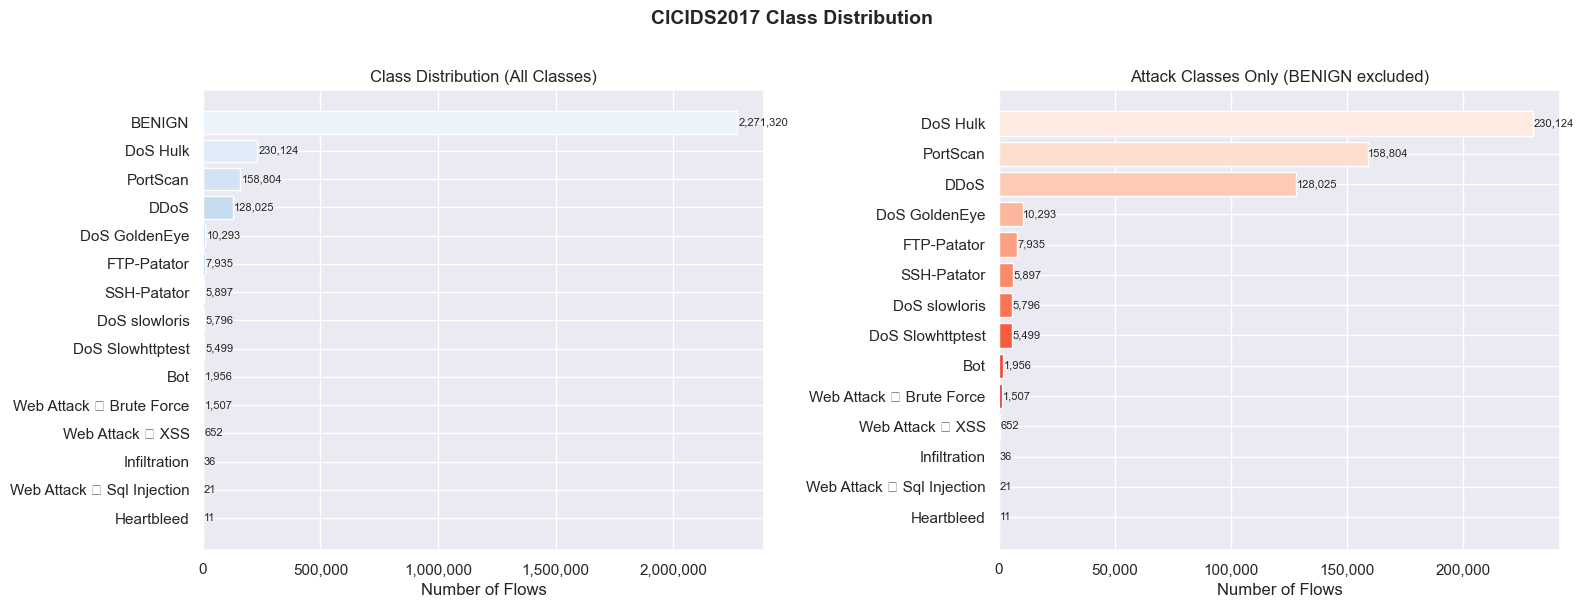

Saved: docs/class_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full count bar chart
ax = axes[0]
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette("Blues_r", len(counts)))
ax.set_xlabel("Number of Flows")
ax.set_title("Class Distribution (All Classes)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)

# Right: minority classes only (exclude BENIGN)
ax2 = axes[1]
minority = counts[counts.index != "BENIGN"]
bars2 = ax2.barh(minority.index[::-1], minority.values[::-1], color=sns.color_palette("Reds_r", len(minority)))
ax2.set_xlabel("Number of Flows")
ax2.set_title("Attack Classes Only (BENIGN excluded)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars2, minority.values[::-1]):
    ax2.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=8)

plt.suptitle("CICIDS2017 Class Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "docs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/class_distribution.png")

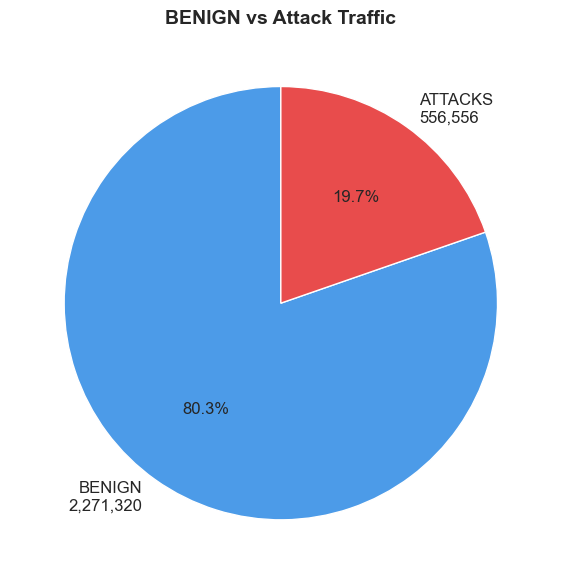

BENIGN: 80.3%  |  Attacks: 19.7%
Saved: docs/benign_vs_attacks.png


In [19]:
# Pie chart: BENIGN vs ALL ATTACKS
benign = counts["BENIGN"]
attacks = counts.drop("BENIGN").sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [benign, attacks],
    labels=[f"BENIGN\n{benign:,}", f"ATTACKS\n{attacks:,}"],
    autopct="%1.1f%%",
    colors=["#4C9BE8", "#E84C4C"],
    startangle=90,
    textprops={"fontsize": 12}
)
ax.set_title("BENIGN vs Attack Traffic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "docs/benign_vs_attacks.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"BENIGN: {benign / len(df) * 100:.1f}%  |  Attacks: {attacks / len(df) * 100:.1f}%")
print("Saved: docs/benign_vs_attacks.png")

---
## Section C — Attack Type Breakdown by Source File

This table is important for your report — it explains which raw CSV contributes which attack types.

In [20]:
source_map = {
    "Monday-WorkingHours.pcap_ISCX.csv": ["BENIGN"],
    "Tuesday-WorkingHours.pcap_ISCX.csv": ["BENIGN", "FTP-Patator", "SSH-Patator"],
    "Wednesday-workingHours.pcap_ISCX.csv": ["BENIGN", "DoS slowloris", "DoS Slowhttptest", "DoS Hulk", "DoS GoldenEye", "Heartbleed"],
    "Thursday-Morning-WebAttacks.pcap_ISCX.csv": ["BENIGN", "Web Attack – Brute Force", "Web Attack – XSS", "Web Attack – Sql Injection"],
    "Thursday-Afternoon-Infilteration.pcap_ISCX.csv": ["BENIGN", "Infiltration"],
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": ["BENIGN", "Bot"],
    "Friday-Afternoon-DDos.pcap_ISCX.csv": ["BENIGN", "DDoS"],
    "Friday-Afternoon-PortScan.pcap_ISCX.csv": ["BENIGN", "PortScan"],
}

rows = []
for filename, labels in source_map.items():
    day = filename.split("-")[0]
    attacks = [l for l in labels if l != "BENIGN"]
    rows.append({"File": filename, "Day": day, "Attack Types": ", ".join(attacks) if attacks else "None (benign baseline)"})

source_df = pd.DataFrame(rows)
source_df

,File,Day,Attack Types
0,Monday-WorkingHours.pcap_ISCX.csv,Monday,None (benign baseline)
1,Tuesday-WorkingHours.pcap_ISCX.csv,Tuesday,"FTP-Patator, SSH-Patator"
2,Wednesday-workingHours.pcap_ISCX.csv,Wednesday,"DoS slowloris, DoS Slowhttptest, DoS Hulk, DoS..."
3,Thursday-Morning-WebAttacks.pcap_ISCX.csv,Thursday,"Web Attack – Brute Force, Web Attack – XSS, We..."
4,Thursday-Afternoon-Infilteration.pcap_ISCX.csv,Thursday,Infiltration
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Friday,Bot
6,Friday-Afternoon-DDos.pcap_ISCX.csv,Friday,DDoS
7,Friday-Afternoon-PortScan.pcap_ISCX.csv,Friday,PortScan


---
## Section D — Feature Statistics

In [21]:
feature_cols = [c for c in df.columns if c != "Label"]
print(f"Total features: {len(feature_cols)}")
print("\nSample feature statistics:")
df[feature_cols].describe().T[["mean", "std", "min", "max"]].head(15)

Total features: 78

Sample feature statistics:


,mean,std,min,max
Destination Port,8.061534e+03,1.827432e+04,0.0,6.553500e+04
Flow Duration,1.480065e+07,3.366750e+07,-13.0,1.200000e+08
Total Fwd Packets,9.368972e+00,7.500527e+02,1.0,2.197590e+05
Total Backward Packets,1.040396e+01,9.978937e+02,0.0,2.919220e+05
Total Length of Fwd Packets,5.498522e+02,9.998639e+03,0.0,1.290000e+07
Total Length of Bwd Packets,1.617903e+04,2.264235e+06,0.0,6.554530e+08
Fwd Packet Length Max,2.078044e+02,7.175183e+02,0.0,2.482000e+04
Fwd Packet Length Min,1.872929e+01,6.035533e+01,0.0,2.325000e+03
Fwd Packet Length Mean,5.825628e+01,1.861733e+02,0.0,5.940857e+03
Fwd Packet Length Std,6.897811e+01,2.813212e+02,0.0,7.125597e+03


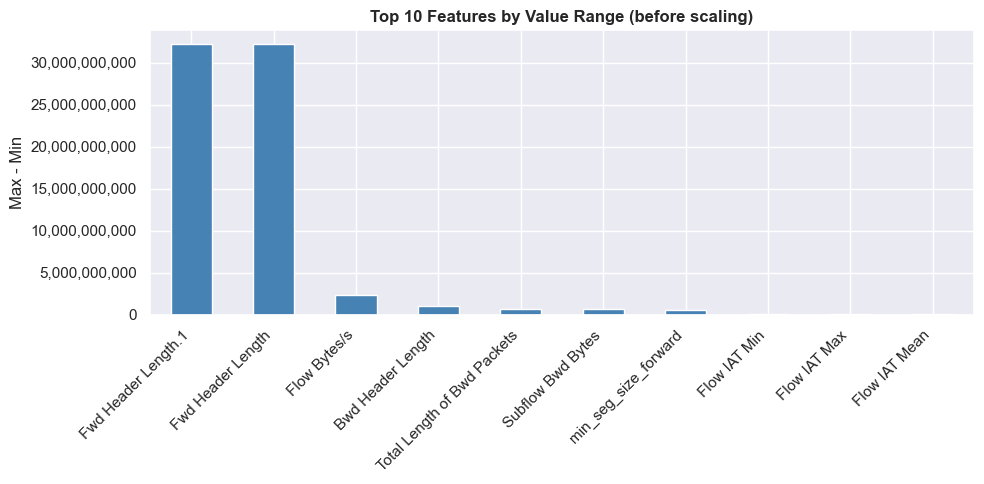

Saved: docs/feature_ranges.png

Note: large value ranges confirm why StandardScaler normalization is necessary.


In [22]:
# Feature value ranges — shows why StandardScaler is needed
ranges = df[feature_cols].max() - df[feature_cols].min()
top_range = ranges.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_range.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 10 Features by Value Range (before scaling)", fontweight="bold")
ax.set_ylabel("Max - Min")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ROOT / "docs/feature_ranges.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/feature_ranges.png")
print("\nNote: large value ranges confirm why StandardScaler normalization is necessary.")

---
## Section E — Feature Importance (from trained model)

In [23]:
model = joblib.load(ROOT / "artifacts/models/model.pkl")
feature_columns = joblib.load(ROOT / "artifacts/models/feature_columns.pkl")

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

print("Top 20 most important features:")
print(importance_df.to_string(index=False))

Top 20 most important features:
                    Feature  Importance
           Destination Port    0.076215
    Init_Win_bytes_backward    0.058285
              Flow IAT Mean    0.030248
          Max Packet Length    0.029730
     Init_Win_bytes_forward    0.025966
       min_seg_size_forward    0.025536
               Flow IAT Max    0.024255
          Subflow Fwd Bytes    0.024165
               Flow IAT Std    0.023870
      Bwd Packet Length Max    0.023848
      Fwd Packet Length Max    0.023152
       Avg Bwd Segment Size    0.022972
Total Length of Fwd Packets    0.022711
Total Length of Bwd Packets    0.022435
          Bwd Header Length    0.021826
         Packet Length Mean    0.020826
              Flow Duration    0.020145
          Subflow Bwd Bytes    0.019950
               Fwd IAT Mean    0.019248
        Average Packet Size    0.019027


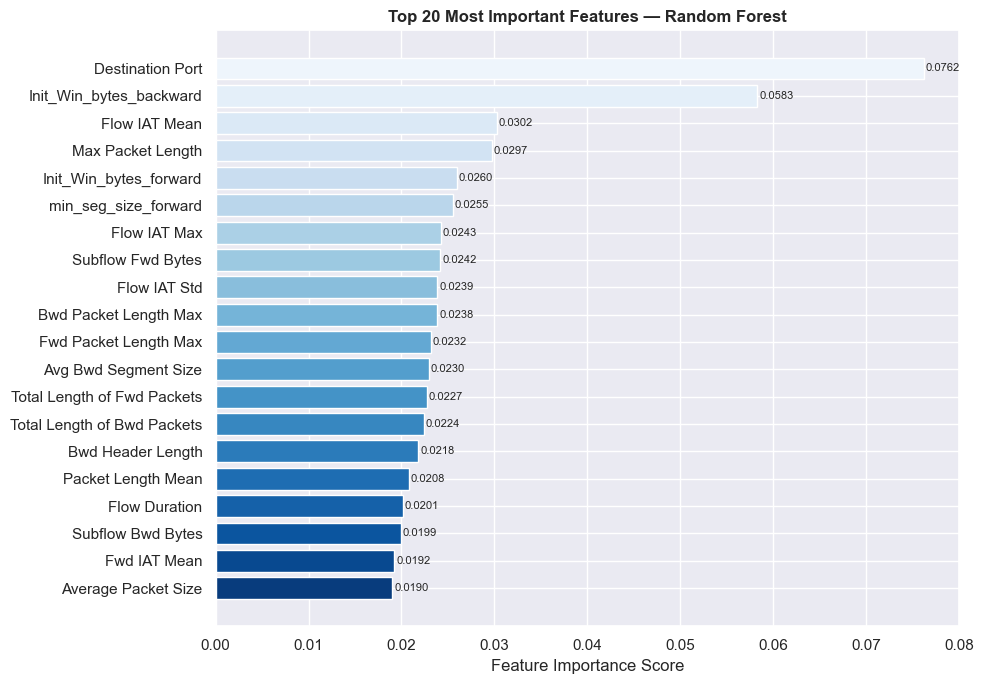

Saved: docs/feature_importance.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
bars = ax.barh(top20["Feature"][::-1], top20["Importance"][::-1],
               color=sns.color_palette("Blues_r", 20))
ax.set_xlabel("Feature Importance Score")
ax.set_title("Top 20 Most Important Features — Random Forest", fontweight="bold")
for bar, val in zip(bars, top20["Importance"][::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "docs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/feature_importance.png")

---
## Section F — Model Comparison Summary

In [25]:
comparison_df = pd.read_csv(ROOT / "artifacts/logs/model_comparison.csv")
print(comparison_df.to_string(index=False))

        model  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  train_time_sec
Decision Tree  0.998612  0.847288     0.998612         0.838396      0.859780           194.8
  Extra Trees  0.998439  0.882365     0.998416         0.928101      0.856834           291.3
Random Forest  0.998301  0.883067     0.998395         0.913519      0.879951           291.9


In [ ]:
comparison_df = pd.read_csv(ROOT / "artifacts/logs/model_comparison.csv")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.2

ax.bar(x - width*1.5, comparison_df["accuracy"],        width, label="Accuracy",        color="#4C9BE8")
ax.bar(x - width*0.5, comparison_df["macro_f1"],         width, label="Macro F1",         color="#E84C4C")
ax.bar(x + width*0.5, comparison_df["weighted_f1"],      width, label="Weighted F1",      color="#4CE89B")
ax.bar(x + width*1.5, comparison_df["cv_weighted_f1_mean"], width, label="CV F1 (mean)",  color="#E8A84C")

# CV error bars
ax.errorbar(x + width*1.5, comparison_df["cv_weighted_f1_mean"],
            yerr=comparison_df["cv_weighted_f1_std"],
            fmt="none", color="white", capsize=4, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["model"])
ax.set_ylim(0.7, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy / Macro F1 / Weighted F1 / CV F1", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "docs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: docs/model_comparison.png")

---
## Summary

| Chart saved | Use in report |
|---|---|
| `docs/class_distribution.png` | Dataset Analysis chapter — class imbalance |
| `docs/benign_vs_attacks.png` | Introduction — 80.3% vs 19.7% |
| `docs/feature_ranges.png` | Preprocessing chapter — justifies StandardScaler |
| `docs/feature_importance.png` | Results chapter — what the model learned |
| `docs/model_comparison.png` | Results chapter — model selection justification |